# 📊 FBG Quality Parameter Analysis
## Understanding Spectral Quality Metrics for Cryogenic Temperature Sensing

**Context:** We are evaluating FBG (Fiber Bragg Grating) sensors for cryogenic temperature monitoring in particle physics detectors. Before purchasing new fibers from Engionic, we study 3 test fibers with different coating technologies to understand the key quality parameters.

| Fiber | Manufacturer | Coating | N sensors | Technology | Status |
|-------|-------------|---------|-----------|------------|--------|
| **DW-3** | Draw Tower (ext.) | Ormocer-T | 4 | Standard (not apodised) | Test sample |
| **PEEK-6** | Engionic | PEEK 400 µm | 3 | Prototype (early batch) | Test sample |
| **POLY-1** | External | Polyimide | 4 | Standard | Test sample |

**New order specs** (Engionic 41260063): PEEK + Polyimide base fiber, **FemtoPlus** (low birefringence), **apodised**, FWHM = 120 ± 30 pm, SLSR ≥ 20 dB, L = 11 ± 1 mm, R = 25 ± 8%.

### Status of Order Confirmation (6 March 2026)

Following a formal design parameter review, IFIC has communicated the following positions to Engionic:

| Parameter | IFIC Position |
|-----------|---------------|
| **FWHM** | 120 ± 30 pm **accepted** (original requirement was < 100 pm) |
| **Insertion loss** | No significant losses observed on samples — **acceptable** |
| **Asymmetry ratio** | < 1% measured; attributed to apodisation — **acceptable** |
| **Coating OD** | 390 µm measured (spec: 400 ± 50 µm); **homogeneity along each fibre is critical** (governs thermal sensitivity) |
| **Wavelength accuracy** | With 1.15 nm spacing + < 150 pm FWHM, pile-up risk is **negligible** |
| **Birefringence** | Standard FemtoPlus **accepted**; interrogator resolves both polarisation states independently |
| **Reflectivity** | **Primary concern** — 25 ± 8% must be confirmed adequate for the full readout chain (FBG → connectors → cables → CF16 flange → interrogator) |

> **Goal:** Use these 3 test fibers to illustrate and understand each quality parameter, validate the accepted tolerances, and identify the remaining open point (reflectivity budget for the complete chain).

*Data: 2026-03-04, FAZT I4G-16 interrogator.*

In [1]:
# ══════════════════════════════════════════════════════════════════════
# §1 — Imports & Presentation Style
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd
import uproot, datetime
from scipy.signal import find_peaks, peak_widths

# ── Presentation style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {'DW-3': '#1f77b4', 'PEEK-6': '#ff7f0e', 'POLY-1': '#d62728'}
POL_COLORS = {'P': '#2196F3', 'S': '#F44336'}

print("✅ Libraries loaded, presentation style configured")

✅ Libraries loaded, presentation style configured


In [2]:
# ══════════════════════════════════════════════════════════════════════
# §2 — Load Data: ROOT spectra + CSV quality metrics
# ══════════════════════════════════════════════════════════════════════

# ── ROOT file: raw spectra ──────────────────────────────────────────
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260304.root"
file = uproot.open(filepath)

# Get latest cycles
def latest_key(f, name):
    cands = [k for k in f.keys() if k.split(";")[0] == name]
    return sorted(cands, key=lambda k: int(k.split(";")[1]))[-1] if cands else None

tree_spectrum = file[latest_key(file, "spectrum")]
data_spectrum = tree_spectrum.arrays(library="np")
spectrum_wav = data_spectrum['wav']

n_espectros, n_pol, n_chan, n_puntos = spectrum_wav.shape
idx_espectro = 50  # representative snapshot

# Wavelength axis
LAMBDA_START, LAMBDA_END = 1529.0, 1568.2
wavelength_axis = np.linspace(LAMBDA_START, LAMBDA_END, n_puntos)
dlam = (LAMBDA_END - LAMBDA_START) / n_puntos  # nm/pt ≈ 0.001

channel_names = {0: 'DW-3', 1: 'PEEK-6', 2: 'POLY-1'}
pol_labels = ['Pol P', 'Pol S']

# ── CSV: pre-computed quality metrics ───────────────────────────────
df = pd.read_csv('FBG_quality_summary_20260304.csv')
df_xpol = pd.read_csv('FBG_quality_summary_20260304_cross_pol.csv')

# Average P+S per sensor
df_avg = df.groupby(['Fibra', 'FBG']).agg({
    'lambda_B_nm': 'mean', 'FWHM_pm': 'mean', 'BW20_pm': 'mean',
    'SF': 'mean', 'Amp_cts': 'mean', 'SNR_dB': 'mean',
    'SLSR_dB': 'mean', 'SAR_pct': 'mean', 'L_mm': 'mean',
}).reset_index()
df_avg['label'] = df_avg['Fibra'] + ' FBG-' + df_avg['FBG'].astype(str)

print(f"✅ Spectra loaded: {spectrum_wav.shape}")
print(f"✅ Quality CSV: {len(df)} rows ({len(df_avg)} sensors × 2 pols)")
print(f"✅ Cross-pol CSV: {len(df_xpol)} rows")
print(f"\n📋 Sensors:")
for _, r in df_avg.iterrows():
    print(f"   {r['label']:18s}  λ={r['lambda_B_nm']:.3f} nm  FWHM={r['FWHM_pm']:.0f} pm  SNR={r['SNR_dB']:.1f} dB")

✅ Spectra loaded: (117, 2, 3, 39200)
✅ Quality CSV: 22 rows (11 sensors × 2 pols)
✅ Cross-pol CSV: 11 rows

📋 Sensors:
   DW-3 FBG-1          λ=1544.952 nm  FWHM=77 pm  SNR=30.2 dB
   DW-3 FBG-2          λ=1550.787 nm  FWHM=79 pm  SNR=30.5 dB
   DW-3 FBG-3          λ=1556.599 nm  FWHM=78 pm  SNR=29.8 dB
   DW-3 FBG-4          λ=1562.367 nm  FWHM=80 pm  SNR=29.9 dB
   PEEK-6 FBG-1        λ=1541.470 nm  FWHM=212 pm  SNR=27.2 dB
   PEEK-6 FBG-2        λ=1544.581 nm  FWHM=212 pm  SNR=27.4 dB
   PEEK-6 FBG-3        λ=1547.494 nm  FWHM=212 pm  SNR=27.4 dB
   POLY-1 FBG-1        λ=1545.109 nm  FWHM=165 pm  SNR=27.8 dB
   POLY-1 FBG-2        λ=1550.945 nm  FWHM=166 pm  SNR=27.2 dB
   POLY-1 FBG-3        λ=1556.729 nm  FWHM=168 pm  SNR=26.8 dB
   POLY-1 FBG-4        λ=1562.437 nm  FWHM=177 pm  SNR=26.6 dB


---
## §3 — Full Spectrum Overview: What Does the Interrogator See?

Each fiber is connected to one optical channel. The interrogator sweeps 1529–1568 nm and records the reflected power at each wavelength. Each **peak** is one FBG sensor.

- **DW-3** (blue): 4 sharp, narrow peaks — ormocer coating, not apodized → visible sidelobes
- **PEEK-6** (orange): 3 broader peaks — PEEK 400µm coating, prototype batch
- **POLY-1** (red): 4 medium peaks — polyimide coating

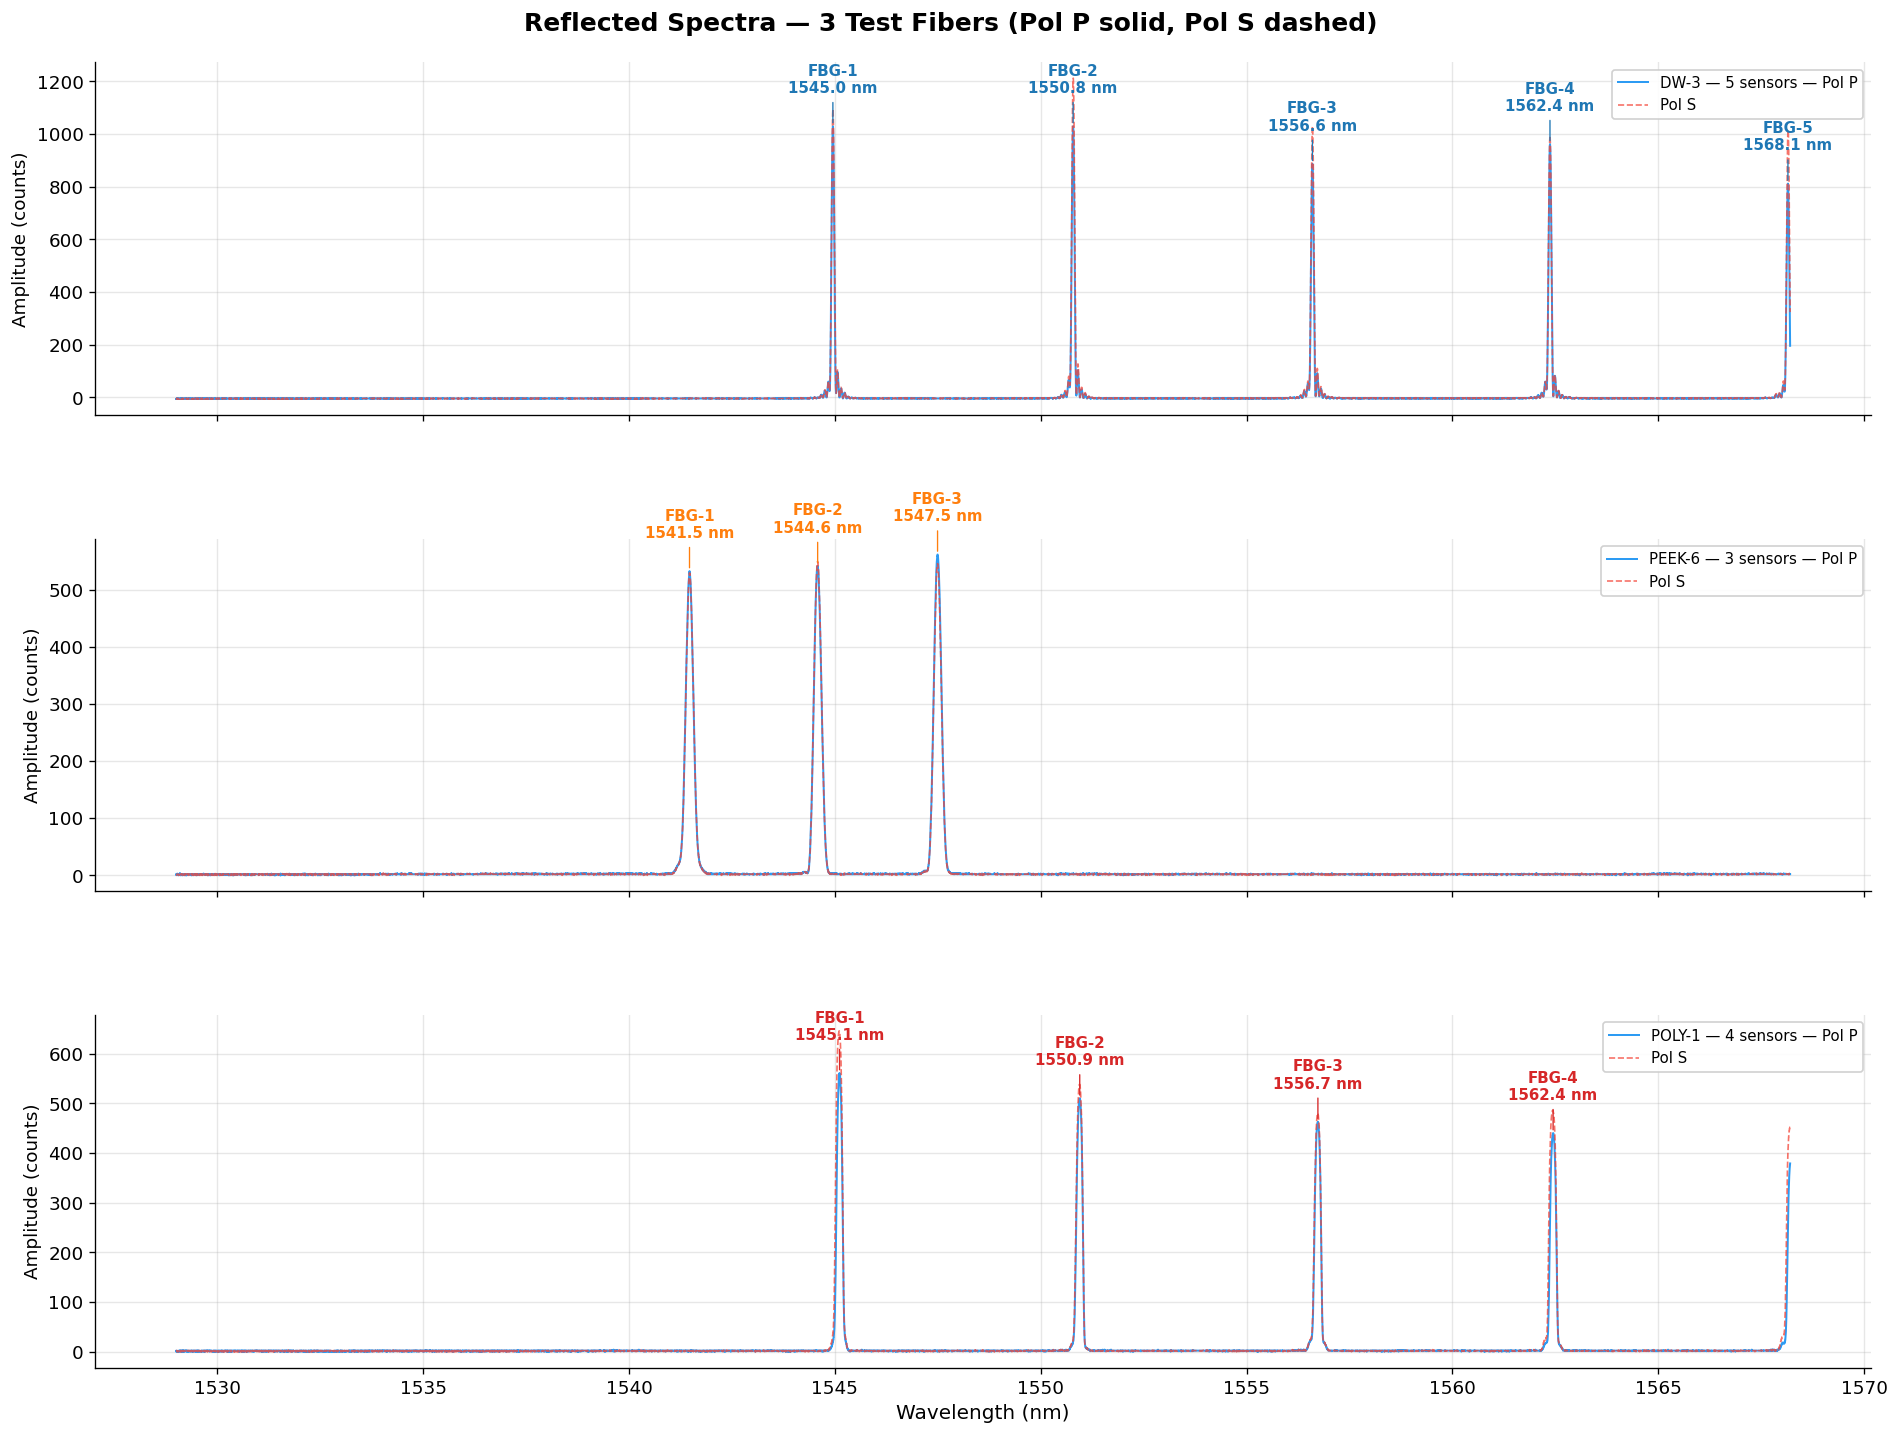

In [3]:
# ══════════════════════════════════════════════════════════════════════
# §3 — Full spectrum overview: 3 fibers side-by-side
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ch, (fiber, color) in enumerate(COLORS.items()):
    ax = axes[ch]
    sig_p = spectrum_wav[idx_espectro, 0, ch, :]
    sig_s = spectrum_wav[idx_espectro, 1, ch, :]

    # Detect peaks for labels
    peaks_idx, _ = find_peaks(sig_p, prominence=sig_p.max() * 0.1, distance=200)
    
    # Plot with fiber name in legend
    ax.plot(wavelength_axis, sig_p, color='#2196F3', linewidth=1.2, alpha=0.95, 
            label=f'{fiber} — {len(peaks_idx)} sensors — Pol P')
    ax.plot(wavelength_axis, sig_s, color='#F44336', linewidth=1.0, alpha=0.75, linestyle='--', 
            label='Pol S')

    for i, pidx in enumerate(peaks_idx):
        lam = wavelength_axis[pidx]
        amp = sig_p[pidx]
        ax.annotate(f'FBG-{i+1}\n{lam:.1f} nm',
                    xy=(lam, amp), xytext=(0, 20),
                    textcoords='offset points', ha='center', fontsize=9,
                    fontweight='bold', color=color,
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8))

    ax.set_ylabel('Amplitude (counts)', fontsize=11)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

axes[-1].set_xlabel('Wavelength (nm)')
fig.suptitle('Reflected Spectra — 3 Test Fibers (Pol P solid, Pol S dashed)',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.96, hspace=0.35)
plt.show()

---
## §4 — Anatomy of an FBG Peak: What Do We Measure?

Zoomed view of one representative peak per fiber, with **all key parameters annotated**:
- **FWHM** (Full Width at Half Maximum): peak width at −3 dB → determines wavelength resolution
- **Sidelobes**: secondary peaks next to the main peak → SLSR measures their suppression
- **SNR**: how much the peak stands above the noise floor
- **Birefringence**: shift between Pol P and Pol S peaks

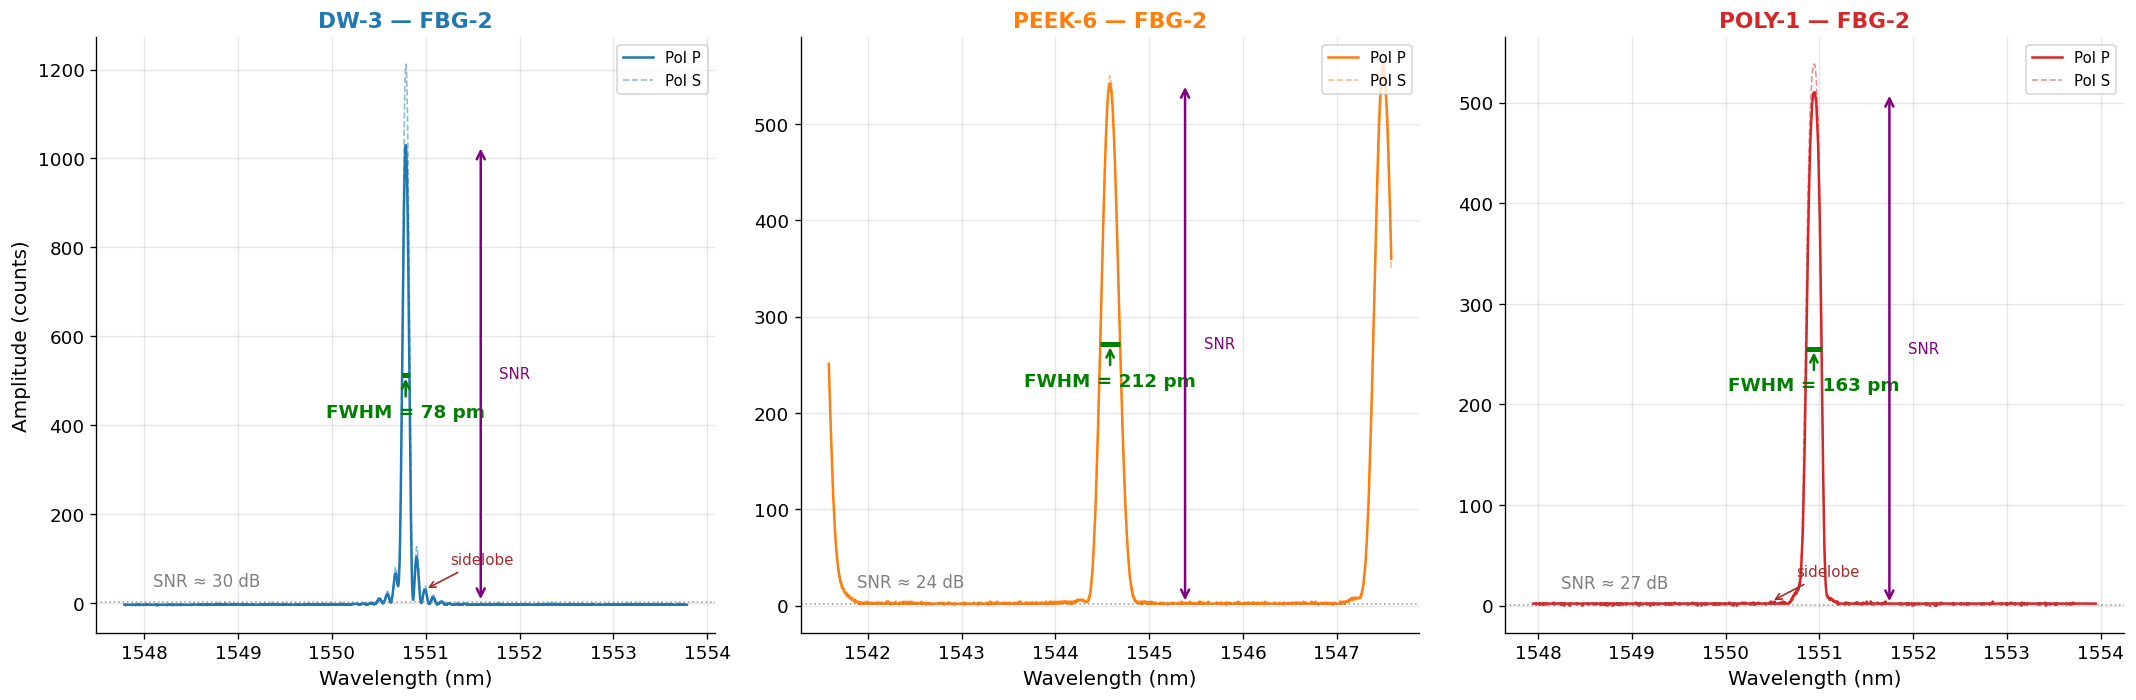

In [4]:
# ══════════════════════════════════════════════════════════════════════
# §4 — Annotated peak anatomy: one peak per fiber
# ══════════════════════════════════════════════════════════════════════

# Pick representative peaks: DW-3 FBG-2, PEEK-6 FBG-2, POLY-1 FBG-2
rep_peaks = [(0, 'DW-3'), (1, 'PEEK-6'), (2, 'POLY-1')]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax_i, (ch, fiber) in enumerate(rep_peaks):
    ax = axes[ax_i]
    sig_p = spectrum_wav[idx_espectro, 0, ch, :]
    sig_s = spectrum_wav[idx_espectro, 1, ch, :]

    # Find peaks
    peaks_idx, props = find_peaks(sig_p, prominence=sig_p.max() * 0.1, distance=200)
    widths, w_heights, left_ips, right_ips = peak_widths(sig_p, peaks_idx, rel_height=0.5)

    # Pick 2nd peak (or 1st if only 1-2)
    pi = min(1, len(peaks_idx) - 1)
    pidx = peaks_idx[pi]
    fw = widths[pi]
    fwhm_pm = fw * dlam * 1e3
    amp = sig_p[pidx]
    lam_peak = wavelength_axis[pidx]

    # Zoom window: ±3 nm
    zoom_nm = 3.0
    mask = (wavelength_axis >= lam_peak - zoom_nm) & (wavelength_axis <= lam_peak + zoom_nm)
    x = wavelength_axis[mask]

    ax.plot(x, sig_p[mask], color=COLORS[fiber], linewidth=1.5, label='Pol P')
    ax.plot(x, sig_s[mask], color=COLORS[fiber], linewidth=1.0, alpha=0.5,
            linestyle='--', label='Pol S')

    # ── FWHM annotation ──
    half = w_heights[pi]
    left_nm = LAMBDA_START + left_ips[pi] * dlam
    right_nm = LAMBDA_START + right_ips[pi] * dlam
    ax.hlines(half, left_nm, right_nm, color='green', linewidth=3, zorder=5)
    ax.annotate(f'FWHM = {fwhm_pm:.0f} pm', xy=((left_nm + right_nm) / 2, half),
                xytext=(0, -25), textcoords='offset points', ha='center',
                fontsize=11, fontweight='bold', color='green',
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

    # ── Noise floor / SNR annotation ──
    # local baseline: 10th percentile in zoom window (more robust)
    baseline = np.percentile(sig_p[mask], 10)
    # Ensure baseline > 0 to avoid log(0)
    if baseline <= 0:
        baseline = np.min(sig_p[mask][sig_p[mask] > 0]) if np.any(sig_p[mask] > 0) else 1.0
    ax.axhline(baseline, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    snr_val = 10 * np.log10(amp / baseline) if baseline > 0 and amp > baseline else 0
    ax.annotate(f'SNR ≈ {snr_val:.0f} dB', xy=(lam_peak - zoom_nm + 0.3, baseline),
                xytext=(0, 10), textcoords='offset points', fontsize=10, color='gray')
    # Arrow from peak to baseline
    ax.annotate('', xy=(lam_peak + 0.8, amp), xytext=(lam_peak + 0.8, baseline),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
    ax.text(lam_peak + 1.0, (amp + baseline) / 2, 'SNR', fontsize=9,
            color='purple', va='center')

    # ── Sidelobes annotation (if visible) ──
    # Find secondary peaks in the zoom window
    sig_zoom = sig_p[mask]
    zoom_peaks, _ = find_peaks(sig_zoom, prominence=baseline * 0.5, distance=20)
    # Exclude the main peak
    main_in_zoom = np.argmax(sig_zoom)
    sidelobes = [p for p in zoom_peaks if abs(p - main_in_zoom) > fw * 1.5]
    if sidelobes:
        sl_idx = max(sidelobes, key=lambda p: sig_zoom[p])
        sl_amp = sig_zoom[sl_idx]
        sl_lam = x[sl_idx]
        # Only annotate if it's clearly a sidelobe (not the main peak)
        if sl_amp > baseline * 2 and sl_amp < amp * 0.5:
            ax.annotate('sidelobe', xy=(sl_lam, sl_amp), xytext=(15, 15),
                        textcoords='offset points', fontsize=9, color='brown',
                        arrowprops=dict(arrowstyle='->', color='brown', lw=1))

    ax.set_title(f'{fiber} — FBG-{pi+1}', fontweight='bold', color=COLORS[fiber], fontsize=13)
    ax.set_xlabel('Wavelength (nm)')
    if ax_i == 0:
        ax.set_ylabel('Amplitude (counts)')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. FWHM — Full Width at Half Maximum

**What it tells us:** The spectral width of the reflected peak, directly related to FBG length and apodisation quality. Narrower peaks allow denser wavelength multiplexing and better strain/temperature resolution.

| Spec | Value |
|------|-------|
| **New order (41260063)** | 120 ± 30 pm → 90 – 150 pm |
| **Previous order (41250327)** | 150 ± 100 pm → 50 – 250 pm |
| **Jordi's guidance** | Push as small as possible, 150 pm hard limit |

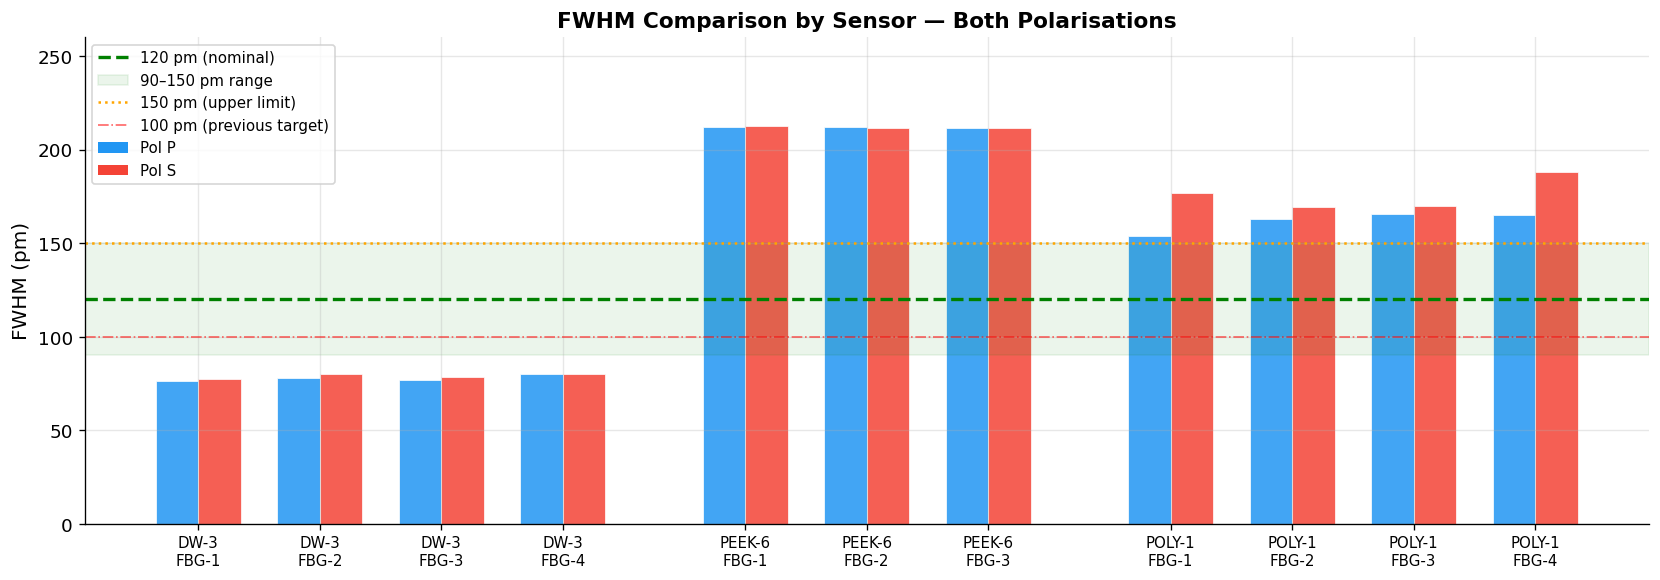


📊  FWHM summary (pm):
         mean   std    min    max
Fibra                            
DW-3     78.4   1.5   76.5   80.2
PEEK-6  211.9   0.4  211.4  212.7
POLY-1  168.9  10.1  153.9  188.1


In [5]:
# ══════════════════════════════════════════════════════════════════════
# §5 — FWHM comparison: bar chart with spec thresholds
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

# Plot FWHM for each sensor, both polarisations
bar_w = 0.35
sensors = df.groupby(['Fibra', 'FBG']).first().reset_index()
labels_all = []
x_ticks = []
x_pos = 0

for fiber in ['DW-3', 'PEEK-6', 'POLY-1']:
    subset = df[df['Fibra'] == fiber].sort_values('FBG')
    fbgs = subset['FBG'].unique()
    for fbg in fbgs:
        row_p = subset[(subset['FBG'] == fbg) & (subset['Pol'] == 'P')]
        row_s = subset[(subset['FBG'] == fbg) & (subset['Pol'] == 'S')]
        if len(row_p) and len(row_s):
            ax.bar(x_pos - bar_w / 2, row_p['FWHM_pm'].values[0], bar_w,
                   color=POL_COLORS['P'], edgecolor='white', linewidth=0.5, alpha=0.85)
            ax.bar(x_pos + bar_w / 2, row_s['FWHM_pm'].values[0], bar_w,
                   color=POL_COLORS['S'], edgecolor='white', linewidth=0.5, alpha=0.85)
        labels_all.append(f'{fiber}\nFBG-{fbg}')
        x_ticks.append(x_pos)
        x_pos += 1
    x_pos += 0.5  # gap between fibers

ax.set_xticks(x_ticks)
ax.set_xticklabels(labels_all, fontsize=9)

# Spec lines
ax.axhline(120, color='green', linewidth=2, linestyle='--', label='120 pm (nominal)')
ax.axhspan(90, 150, color='green', alpha=0.08, label='90–150 pm range')
ax.axhline(150, color='orange', linewidth=1.5, linestyle=':', label='150 pm (upper limit)')

# Previous target
ax.axhline(100, color='red', linewidth=1, linestyle='-.', alpha=0.6,
           label='100 pm (previous target)')

# Custom legend entries for Pol
from matplotlib.patches import Patch
handles, lbs = ax.get_legend_handles_labels()
handles += [Patch(facecolor=POL_COLORS['P'], label='Pol P'),
            Patch(facecolor=POL_COLORS['S'], label='Pol S')]
ax.legend(handles=handles, loc='upper left', fontsize=9)

ax.set_ylabel('FWHM (pm)')
ax.set_title('FWHM Comparison by Sensor — Both Polarisations', fontweight='bold', fontsize=13)
ax.set_ylim(0, max(df['FWHM_pm'].max() * 1.15, 260))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
print("\n📊  FWHM summary (pm):")
print(df.groupby('Fibra')['FWHM_pm'].agg(['mean', 'std', 'min', 'max']).round(1))

---
## 6. SLSR — Side-Lobe Suppression Ratio

**What it tells us:** How well the FBG's apodisation suppresses secondary spectral lobes around the main peak. Poor SLSR can cause crosstalk between adjacent FBGs and degrade peak-finding accuracy.

| Spec | Value |
|------|-------|
| **New order (41260063)** | ≥ 20 dB (apodised) |
| **Previous order (41250327)** | ≥ 15 dB |
| **Jordi's guidance** | Not critical—"we can mitigate offline" |

> **Note:** DW-3 fibres were inscribed *without* apodisation, so they have strong sidelobes by design. PEEK-6 and POLY-1 should be apodised.

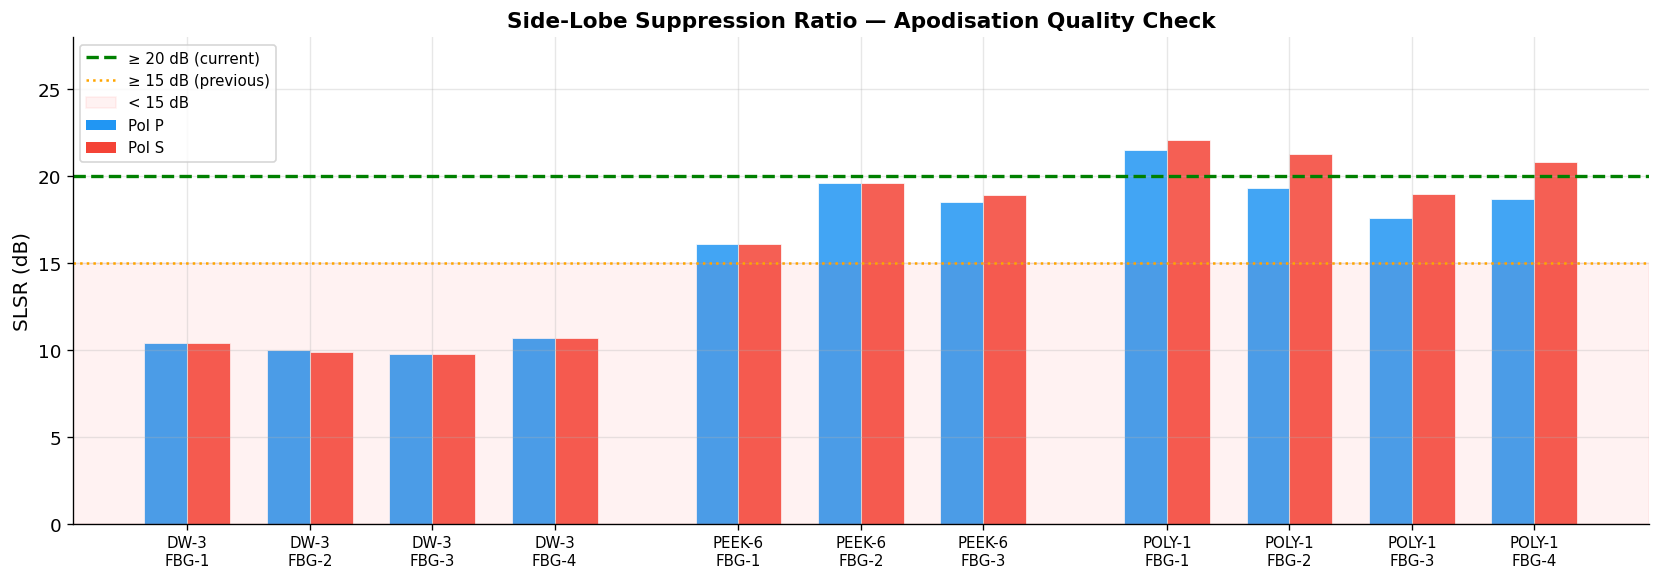


📊  SLSR summary (dB):
        mean  std   min   max
Fibra                        
DW-3    10.2  0.4   9.8  10.7
PEEK-6  18.1  1.6  16.1  19.6
POLY-1  20.0  1.6  17.6  22.1


In [6]:
# ══════════════════════════════════════════════════════════════════════
# §6 — SLSR comparison: grouped bars with spec thresholds
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

bar_w = 0.35
x_pos = 0
labels_all, x_ticks = [], []

for fiber in ['DW-3', 'PEEK-6', 'POLY-1']:
    subset = df[df['Fibra'] == fiber].sort_values('FBG')
    fbgs = subset['FBG'].unique()
    for fbg in fbgs:
        row_p = subset[(subset['FBG'] == fbg) & (subset['Pol'] == 'P')]
        row_s = subset[(subset['FBG'] == fbg) & (subset['Pol'] == 'S')]
        if len(row_p) and len(row_s):
            ax.bar(x_pos - bar_w / 2, row_p['SLSR_dB'].values[0], bar_w,
                   color=POL_COLORS['P'], edgecolor='white', linewidth=0.5, alpha=0.85)
            ax.bar(x_pos + bar_w / 2, row_s['SLSR_dB'].values[0], bar_w,
                   color=POL_COLORS['S'], edgecolor='white', linewidth=0.5, alpha=0.85)
        labels_all.append(f'{fiber}\nFBG-{fbg}')
        x_ticks.append(x_pos)
        x_pos += 1
    x_pos += 0.5

ax.set_xticks(x_ticks)
ax.set_xticklabels(labels_all, fontsize=9)

# Spec lines
ax.axhline(20, color='green', linewidth=2, linestyle='--', label='≥ 20 dB (current)')
ax.axhline(15, color='orange', linewidth=1.5, linestyle=':', label='≥ 15 dB (previous)')

# Shade fail zone
ax.axhspan(0, 15, color='red', alpha=0.05, label='< 15 dB')

from matplotlib.patches import Patch
handles, lbs = ax.get_legend_handles_labels()
handles += [Patch(facecolor=POL_COLORS['P'], label='Pol P'),
            Patch(facecolor=POL_COLORS['S'], label='Pol S')]
ax.legend(handles=handles, loc='upper left', fontsize=9)

ax.set_ylabel('SLSR (dB)')
ax.set_title('Side-Lobe Suppression Ratio — Apodisation Quality Check', fontweight='bold', fontsize=13)
ax.set_ylim(0, max(df['SLSR_dB'].max() * 1.15, 28))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊  SLSR summary (dB):")
print(df.groupby('Fibra')['SLSR_dB'].agg(['mean', 'std', 'min', 'max']).round(1))

---
## 7. Birefringence — Polarisation Dependence

**What it tells us:** The wavelength shift between the two polarisation states (P and S). FBGs with high birefringence show polarisation-dependent wavelength errors. The **FemtoPlus** inscription process used for the new order minimises birefringence.

| Spec | Value |
|------|-------|
| **New order (41260063)** | FemtoPlus → birefringence < 5 pm |
| **Jordi's guidance** | 5 pm manageable, but "under strain it might get enhanced" |

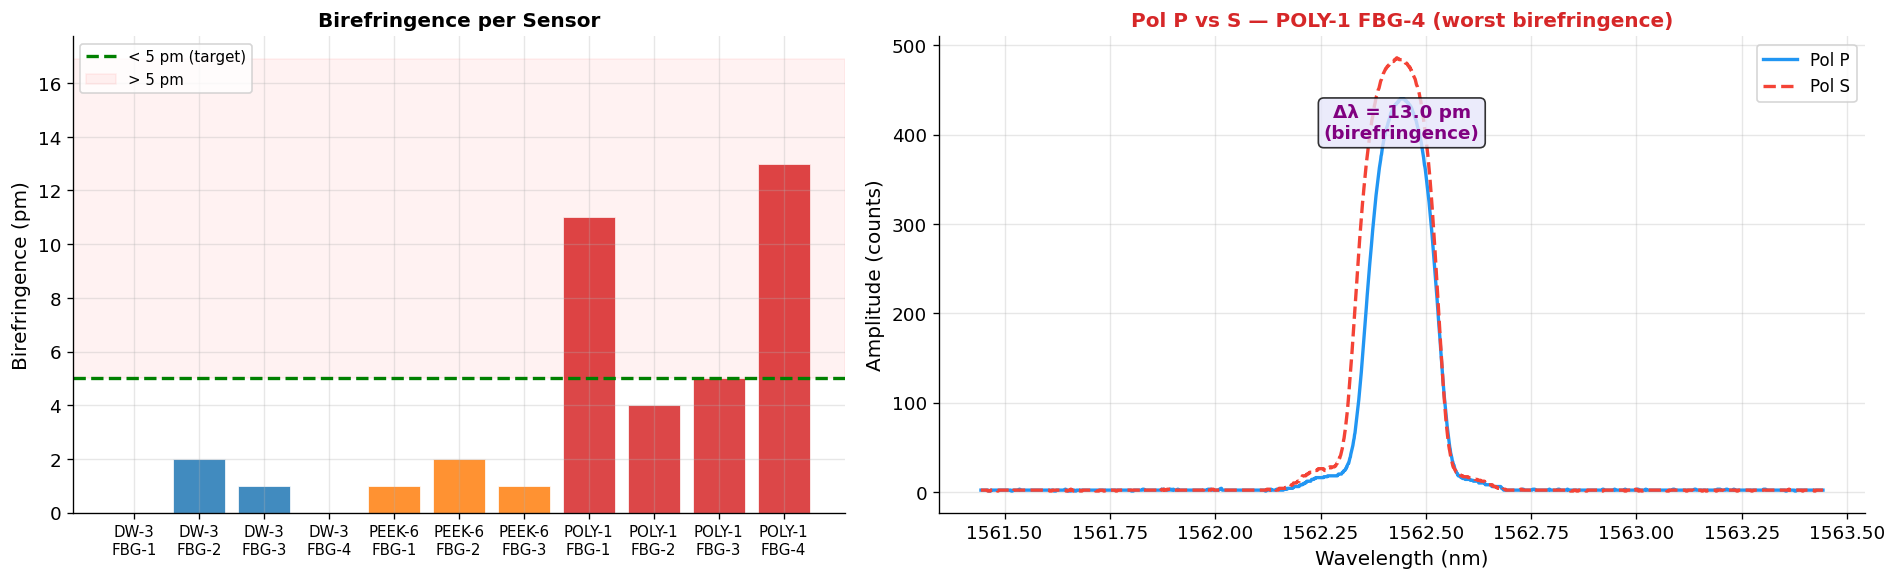


📊  Worst birefringence: POLY-1 FBG-4 = 13.0 pm

📊  Birefringence summary (pm):
        mean  std  min   max
Fibra                       
DW-3     0.8  1.0  0.0   2.0
PEEK-6   1.3  0.6  1.0   2.0
POLY-1   8.2  4.4  4.0  13.0


In [7]:
# ══════════════════════════════════════════════════════════════════════
# §7 — Birefringence: bar chart + P vs S overlay for worst case
# ══════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 1.2]})

# ── Left panel: birefringence bar chart ──
sensors = df_xpol.sort_values(['Fibra', 'FBG'])
bar_colors = [COLORS[f] for f in sensors['Fibra']]
labels_biref = [f"{r['Fibra']}\nFBG-{r['FBG']}" for _, r in sensors.iterrows()]

ax1.bar(range(len(sensors)), sensors['birefringence_pm'], color=bar_colors,
        edgecolor='white', linewidth=0.5, alpha=0.85)
ax1.axhline(5, color='green', linewidth=2, linestyle='--', label='< 5 pm (target)')
ax1.axhspan(5, max(sensors['birefringence_pm'].max() * 1.3, 15),
            color='red', alpha=0.05, label='> 5 pm')
ax1.set_xticks(range(len(sensors)))
ax1.set_xticklabels(labels_biref, fontsize=9)
ax1.set_ylabel('Birefringence (pm)')
ax1.set_title('Birefringence per Sensor', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# ── Right panel: P vs S overlay for highest-birefringence sensor ──
worst = sensors.loc[sensors['birefringence_pm'].idxmax()]
fiber_w = worst['Fibra']
fbg_w = int(worst['FBG'])
ch_w = {'DW-3': 0, 'PEEK-6': 1, 'POLY-1': 2}[fiber_w]

# Get peak idx for this FBG from the quality table
peak_row = df[(df['Fibra'] == fiber_w) & (df['FBG'] == fbg_w) & (df['Pol'] == 'P')]
if len(peak_row):
    lam_center = peak_row['lambda_B_nm'].values[0]
else:
    # Fallback: use cross-pol mean
    lam_center = worst['lambda_mean_nm']

# Zoom window
zoom = 1.0  # nm
mask = (wavelength_axis >= lam_center - zoom) & (wavelength_axis <= lam_center + zoom)
x = wavelength_axis[mask]
sig_p = spectrum_wav[idx_espectro, 0, ch_w, :][mask]
sig_s = spectrum_wav[idx_espectro, 1, ch_w, :][mask]

ax2.plot(x, sig_p, color=POL_COLORS['P'], linewidth=2, label='Pol P')
ax2.plot(x, sig_s, color=POL_COLORS['S'], linewidth=2, label='Pol S', linestyle='--')

# Annotate the shift
biref_val = worst['birefringence_pm']
ax2.annotate(f'Δλ = {biref_val:.1f} pm\n(birefringence)',
             xy=(lam_center, sig_p.max() * 0.9), fontsize=11, fontweight='bold',
             ha='center', color='purple',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lavender', alpha=0.8))

ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('Amplitude (counts)')
ax2.set_title(f'Pol P vs S — {fiber_w} FBG-{fbg_w} (worst birefringence)',
              fontweight='bold', fontsize=12, color=COLORS[fiber_w])
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊  Worst birefringence: {fiber_w} FBG-{fbg_w} = {biref_val:.1f} pm")
print("\n📊  Birefringence summary (pm):")
print(df_xpol.groupby('Fibra')['birefringence_pm'].agg(['mean', 'std', 'min', 'max']).round(1))

---
## 8. FBG Length

**What it tells us:** Longer gratings produce narrower peaks (smaller FWHM) and higher reflectivity, but require more precise fabrication. The grating length $L$ is estimated from the spectral bandwidth at –20 dB using the formula:

$$L \approx \frac{\lambda_B^2}{\Delta\lambda_{-20\text{dB}} \cdot n_\text{eff}}$$

| Spec | Value |
|------|-------|
| **New order (41260063)** | 11 ± 1 mm → 10 – 12 mm |
| **Previous order (41250327)** | 10 ± 2 mm → 8 – 12 mm |

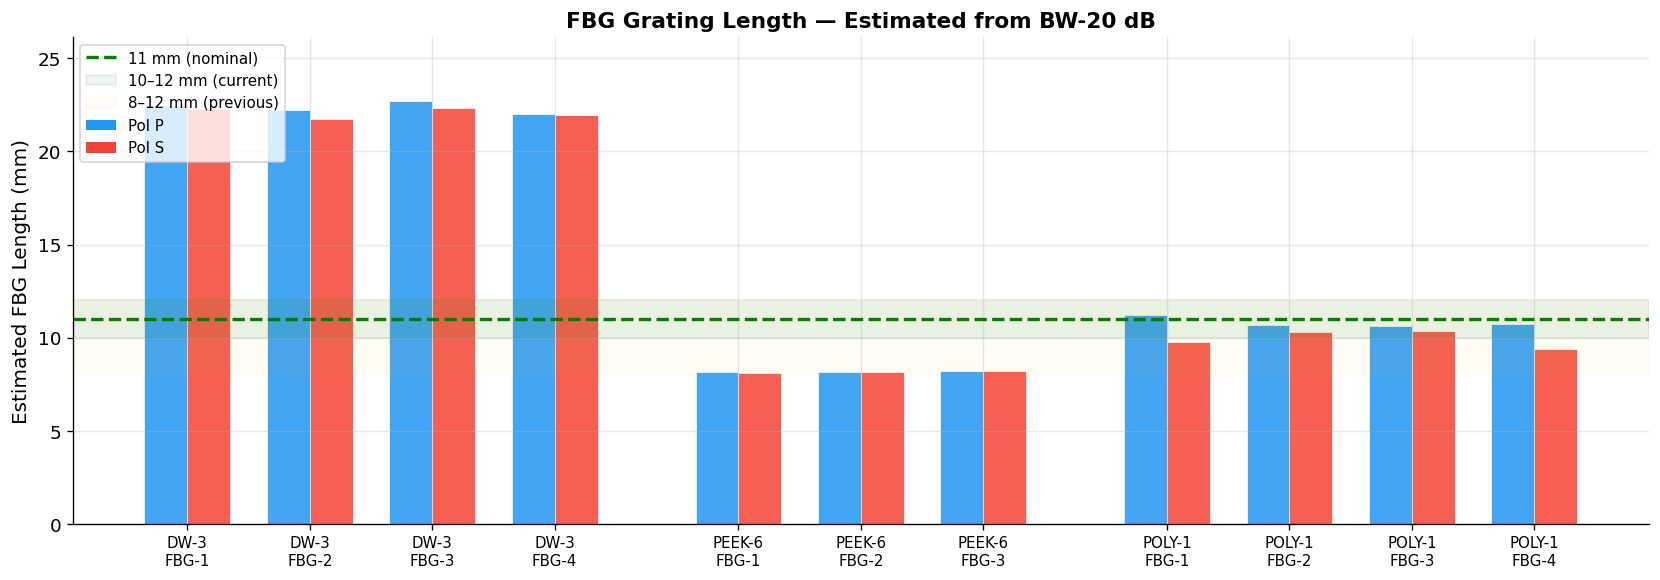


📊  FBG length summary (mm):
        mean  std   min   max
Fibra                        
DW-3    22.2  0.3  21.7  22.7
PEEK-6   8.2  0.0   8.1   8.2
POLY-1  10.4  0.6   9.4  11.2


In [8]:
# ══════════════════════════════════════════════════════════════════════
# §8 — FBG Length comparison
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

bar_w = 0.35
x_pos = 0
labels_all, x_ticks = [], []

for fiber in ['DW-3', 'PEEK-6', 'POLY-1']:
    subset = df[df['Fibra'] == fiber].sort_values('FBG')
    fbgs = subset['FBG'].unique()
    for fbg in fbgs:
        row_p = subset[(subset['FBG'] == fbg) & (subset['Pol'] == 'P')]
        row_s = subset[(subset['FBG'] == fbg) & (subset['Pol'] == 'S')]
        if len(row_p) and len(row_s):
            ax.bar(x_pos - bar_w / 2, row_p['L_mm'].values[0], bar_w,
                   color=POL_COLORS['P'], edgecolor='white', linewidth=0.5, alpha=0.85)
            ax.bar(x_pos + bar_w / 2, row_s['L_mm'].values[0], bar_w,
                   color=POL_COLORS['S'], edgecolor='white', linewidth=0.5, alpha=0.85)
        labels_all.append(f'{fiber}\nFBG-{fbg}')
        x_ticks.append(x_pos)
        x_pos += 1
    x_pos += 0.5

ax.set_xticks(x_ticks)
ax.set_xticklabels(labels_all, fontsize=9)

# Spec bands
ax.axhline(11, color='green', linewidth=2, linestyle='--', label='11 mm (nominal)')
ax.axhspan(10, 12, color='green', alpha=0.08, label='10–12 mm (current)')
ax.axhspan(8, 12, color='orange', alpha=0.04, label='8–12 mm (previous)')

from matplotlib.patches import Patch
handles, lbs = ax.get_legend_handles_labels()
handles += [Patch(facecolor=POL_COLORS['P'], label='Pol P'),
            Patch(facecolor=POL_COLORS['S'], label='Pol S')]
ax.legend(handles=handles, loc='upper left', fontsize=9)

ax.set_ylabel('Estimated FBG Length (mm)')
ax.set_title('FBG Grating Length — Estimated from BW-20 dB', fontweight='bold', fontsize=13)
ax.set_ylim(0, max(df['L_mm'].max() * 1.15, 25))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊  FBG length summary (mm):")
print(df.groupby('Fibra')['L_mm'].agg(['mean', 'std', 'min', 'max']).round(1))

---
## 9. Temporal Stability of Peak Wavelength

**What it tells us:** How much the detected Bragg wavelength fluctuates over time (at constant temperature/strain). High dispersion indicates noisy or unstable peaks. We compute the standard deviation $\sigma(\lambda_B)$ for each FBG across all 117 time snapshots.

wav_raw shape: (29375, 2, 11)
time_raw shape: (29375, 2)
time_raw dtype: float64
time_raw[0]: [1.77263387e+09 1.77263387e+09]

✅ Peak tree loaded: 29375 entries → 29375 after time filter (≥ 13:50h)
   Shape: (29375, 2, 11) — units: meters


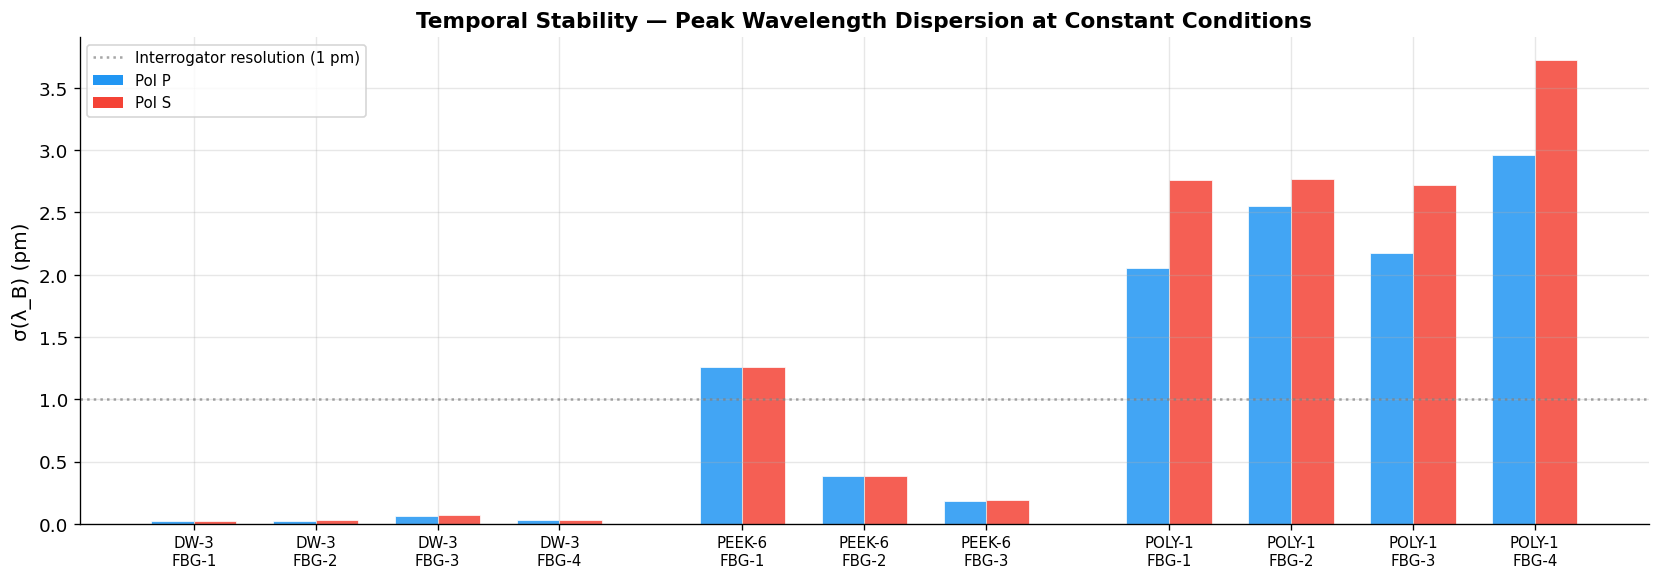


📊  σ(λ_B) summary (pm):
        mean   std   min   max
Fibra                         
DW-3    0.04  0.02  0.02  0.07
PEEK-6  0.61  0.51  0.18  1.26
POLY-1  2.71  0.51  2.05  3.72


In [9]:
# ══════════════════════════════════════════════════════════════════════
# §9 — Temporal stability: load peak tree & compute σ(λ_B) per sensor
# ══════════════════════════════════════════════════════════════════════

import datetime

# Load peak tree (wav is in METERS, shape: [n_entries, 2_pols, 11_sensors])
data_peak = file['peak;2'].arrays(library='np')
wav_raw = data_peak['wav']
time_raw = data_peak['t']

print(f"wav_raw shape: {wav_raw.shape}")
print(f"time_raw shape: {time_raw.shape if hasattr(time_raw, 'shape') else type(time_raw)}")
print(f"time_raw dtype: {time_raw.dtype}")
if hasattr(time_raw, 'shape') and len(time_raw.shape) > 1:
    print(f"time_raw[0]: {time_raw[0]}")

# Flatten time: if multidimensional, take the first column
if hasattr(time_raw, 'shape') and len(time_raw.shape) > 1:
    time_flat = time_raw[:, 0] if time_raw.shape[1] > 0 else time_raw.flatten()
else:
    time_flat = np.atleast_1d(time_raw)

time_flat = time_flat[:wav_raw.shape[0]]

# Time filtering: only use data from 13:50h onwards (stable conditions)
t_inicio = 13 * 3600 + 50 * 60
fecha = datetime.date(2026, 3, 4)
t_first = datetime.datetime.combine(fecha, datetime.datetime.fromtimestamp(0).time())
TIME_SHIFT = datetime.timedelta(hours=1)

times_dt = np.array([t_first + datetime.timedelta(seconds=float(t)) + TIME_SHIFT
                     for t in time_flat])
mask_time = np.array([t.hour * 3600 + t.minute * 60 + t.second >= t_inicio
                      for t in times_dt])

wav_filt = wav_raw[mask_time]    # shape: (N, 2, 11) in meters
times_filt = times_dt[mask_time]

print(f"\n✅ Peak tree loaded: {wav_raw.shape[0]} entries → {wav_filt.shape[0]} after time filter (≥ 13:50h)")
print(f"   Shape: {wav_filt.shape} — units: meters")

# Sensor map: global index → (fiber, FBG)
sensor_map = []
for fiber, n_sens in [('DW-3', 4), ('PEEK-6', 3), ('POLY-1', 4)]:
    for fbg in range(1, n_sens + 1):
        sensor_map.append((fiber, fbg))

# Robust outlier filter using MAD
def robust_filter(data, sigma=3.0):
    med = np.median(data)
    mad = np.median(np.abs(data - med)) * 1.4826
    if mad == 0:
        return np.ones(len(data), dtype=bool)
    return (data >= med - sigma * mad) & (data <= med + sigma * mad)

# Compute σ per sensor per polarisation
stability_rows = []
for s_idx, (fiber, fbg) in enumerate(sensor_map):
    if s_idx >= wav_filt.shape[2]:
        break
    for pol_i, pol_name in enumerate(['P', 'S']):
        wav_series = wav_filt[:, pol_i, s_idx]
        mask_ok = robust_filter(wav_series)
        wav_clean = wav_series[mask_ok]
        sigma_pm = np.std(wav_clean) * 1e12   # meters → pm
        iqr_pm = (np.percentile(wav_clean, 75) - np.percentile(wav_clean, 25)) * 1e12
        stability_rows.append({
            'Fibra': fiber, 'FBG': fbg, 'Pol': pol_name,
            'sigma_pm': sigma_pm, 'IQR_pm': iqr_pm,
            'n_points': len(wav_clean)
        })

df_stab = pd.DataFrame(stability_rows)

# ── Plot: σ(λ_B) per sensor ──
fig, ax = plt.subplots(figsize=(14, 5))

bar_w = 0.35
x_pos = 0
labels_all, x_ticks = [], []

for fiber in ['DW-3', 'PEEK-6', 'POLY-1']:
    subset = df_stab[df_stab['Fibra'] == fiber].sort_values('FBG')
    fbgs = subset['FBG'].unique()
    for fbg in fbgs:
        row_p = subset[(subset['FBG'] == fbg) & (subset['Pol'] == 'P')]
        row_s = subset[(subset['FBG'] == fbg) & (subset['Pol'] == 'S')]
        if len(row_p) and len(row_s):
            ax.bar(x_pos - bar_w / 2, row_p['sigma_pm'].values[0], bar_w,
                   color=POL_COLORS['P'], edgecolor='white', linewidth=0.5, alpha=0.85)
            ax.bar(x_pos + bar_w / 2, row_s['sigma_pm'].values[0], bar_w,
                   color=POL_COLORS['S'], edgecolor='white', linewidth=0.5, alpha=0.85)
        labels_all.append(f'{fiber}\nFBG-{fbg}')
        x_ticks.append(x_pos)
        x_pos += 1
    x_pos += 0.5

ax.set_xticks(x_ticks)
ax.set_xticklabels(labels_all, fontsize=9)

# Interrogator resolution
ax.axhline(1, color='gray', linewidth=1.5, linestyle=':', alpha=0.7,
           label='Interrogator resolution (1 pm)')

from matplotlib.patches import Patch
handles, lbs = ax.get_legend_handles_labels()
handles += [Patch(facecolor=POL_COLORS['P'], label='Pol P'),
            Patch(facecolor=POL_COLORS['S'], label='Pol S')]
ax.legend(handles=handles, loc='upper left', fontsize=9)

ax.set_ylabel('σ(λ_B) (pm)')
ax.set_title('Temporal Stability — Peak Wavelength Dispersion at Constant Conditions',
             fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊  σ(λ_B) summary (pm):")
print(df_stab.groupby('Fibra')['sigma_pm'].agg(['mean', 'std', 'min', 'max']).round(2))

---
## 10. Quality Control Summary — Dual Threshold Heatmap

We evaluate each FBG (averaged P+S) against **two sets of criteria**:

| Parameter | Engionic Spec (accepted) | IFIC Ideal Target |
|-----------|--------------------------|-------------------|
| FWHM | < 150 pm (upper bound of 120 ± 30 pm) | < 120 pm (nominal) |
| SLSR | ≥ 20 dB | ≥ 20 dB |
| FBG Length | 10 – 12 mm | 10 – 12 mm |
| Birefringence | < 5 pm (FemtoPlus) | < 3 pm |

Additional monitored parameters (no vendor spec, IFIC internal):
| Parameter | IFIC Target | Notes |
|-----------|-------------|-------|
| SNR | > 25 dB | Relevant for reflectivity budget |
| SAR | < 10% | "Very high symmetry (<1%) measured" — Jordi |

> **Legend:** Green = Pass both | Yellow = Pass Engionic, fail IFIC ideal | Red = Fail Engionic spec
>
> **Note:** Reflectivity is not assessed here (no spectral-domain measurement available) — it remains the primary open point pending Engionic confirmation for the full readout chain.

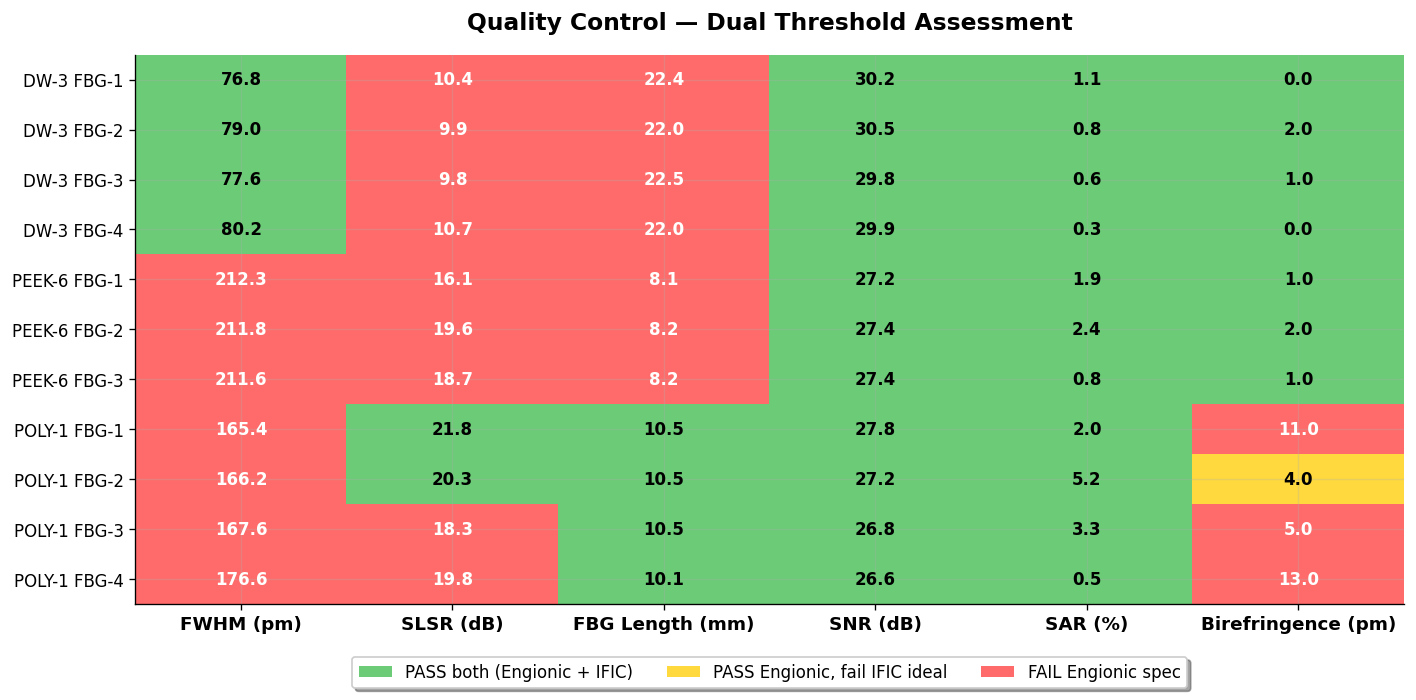


📊  Pass rate (both criteria):
   FWHM (pm)                : 4/11 pass CERN, 4/11 pass Engionic
   SLSR (dB)                : 2/11 pass CERN, 2/11 pass Engionic
   FBG Length (mm)          : 4/11 pass CERN, 4/11 pass Engionic
   SNR (dB)                 : 11/11 pass CERN, 11/11 pass Engionic
   SAR (%)                  : 11/11 pass CERN, 11/11 pass Engionic
   Birefringence (pm)       : 7/11 pass CERN, 8/11 pass Engionic


In [10]:
# ══════════════════════════════════════════════════════════════════════
# §10 — QC Heatmap with dual thresholds (Engionic spec vs CERN target)
# ══════════════════════════════════════════════════════════════════════

# Merge birefringence data into df_avg
df_qc = df_avg.merge(df_xpol[['Fibra', 'FBG', 'birefringence_pm']], on=['Fibra', 'FBG'], how='left')

# Define dual-threshold criteria: (parameter, direction, engionic_limit, cern_limit)
# direction: '<' means pass if value < limit, '>' means pass if value > limit
criteria = [
    ('FWHM_pm',         '<',  150,   120,  'FWHM (pm)'),
    ('SLSR_dB',         '>',  20,    20,   'SLSR (dB)'),
    ('L_mm',            'in', (10, 12), (10, 12), 'FBG Length (mm)'),
    ('SNR_dB',          '>',  25,    25,   'SNR (dB)'),
    ('SAR_pct',         '<',  10,    10,   'SAR (%)'),
    ('birefringence_pm','<',  5,     3,    'Birefringence (pm)'),
]

# Build the heatmap matrix: 0 = fail Engionic, 1 = pass Engionic only, 2 = pass both
sensor_labels = [f"{r['Fibra']} FBG-{int(r['FBG'])}" for _, r in df_qc.iterrows()]
n_sensors = len(df_qc)
n_criteria = len(criteria)

heat = np.zeros((n_sensors, n_criteria), dtype=int)
values = np.empty((n_sensors, n_criteria), dtype=object)

for j, (col, dirn, eng_lim, cern_lim, label) in enumerate(criteria):
    for i, (_, row) in enumerate(df_qc.iterrows()):
        val = row.get(col, np.nan)
        if pd.isna(val):
            heat[i, j] = 0
            values[i, j] = '—'
            continue

        if dirn == '<':
            pass_eng = val < eng_lim
            pass_cern = val < cern_lim
        elif dirn == '>':
            pass_eng = val > eng_lim
            pass_cern = val > cern_lim
        elif dirn == 'in':
            pass_eng = eng_lim[0] <= val <= eng_lim[1]
            pass_cern = cern_lim[0] <= val <= cern_lim[1]

        if pass_eng and pass_cern:
            heat[i, j] = 2
        elif pass_eng:
            heat[i, j] = 1
        else:
            heat[i, j] = 0

        # Format display value
        values[i, j] = f'{val:.1f}'

# Custom colormap: red(0) → yellow(1) → green(2)
from matplotlib.colors import ListedColormap
cmap_qc = ListedColormap(['#FF6B6B', '#FFD93D', '#6BCB77'])

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heat, cmap=cmap_qc, aspect='auto', vmin=0, vmax=2)

# Labels
ax.set_xticks(range(n_criteria))
ax.set_xticklabels([c[4] for c in criteria], fontsize=11, fontweight='bold')
ax.set_yticks(range(n_sensors))
ax.set_yticklabels(sensor_labels, fontsize=10)

# Annotate with values
for i in range(n_sensors):
    for j in range(n_criteria):
        ax.text(j, i, values[i, j], ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='black' if heat[i, j] > 0 else 'white')

# Color bar legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#6BCB77', label='PASS both (Engionic + IFIC)'),
    Patch(facecolor='#FFD93D', label='PASS Engionic, fail IFIC ideal'),
    Patch(facecolor='#FF6B6B', label='FAIL Engionic spec'),
]
ax.legend(handles=legend_elements, loc='upper center',
          bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10,
          frameon=True, fancybox=True, shadow=True)

ax.set_title('Quality Control — Dual Threshold Assessment',
             fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n📊  Pass rate (both criteria):")
for j, (col, dirn, eng_lim, cern_lim, label) in enumerate(criteria):
    n_pass_both = np.sum(heat[:, j] == 2)
    n_pass_eng = np.sum(heat[:, j] >= 1)
    print(f"   {label:25s}: {n_pass_both}/{n_sensors} pass CERN, {n_pass_eng}/{n_sensors} pass Engionic")

---
## 11. Vendor Spec vs Measured — Comparison Table

Direct comparison between what the new Engionic order (41260063) specifies and what we actually measured on the 3 test fibers.

> **Key insight:** The test fibers (especially PEEK-6) were manufactured under the *previous* order (41250327), which had much looser tolerances. The new order is significantly tighter.

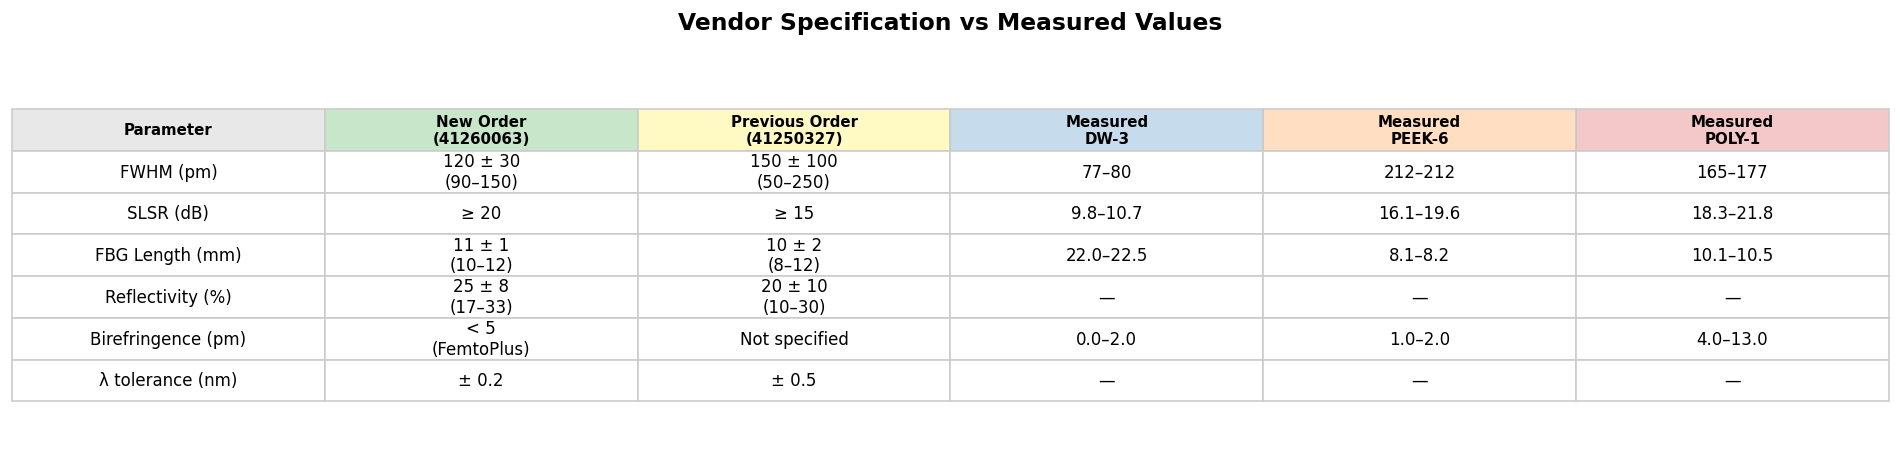

In [11]:
# ══════════════════════════════════════════════════════════════════════
# §11 — Vendor Spec vs Measured — styled comparison table
# ══════════════════════════════════════════════════════════════════════

# Build comparison DataFrame
comparison_data = {
    'Parameter': ['FWHM (pm)', 'SLSR (dB)', 'FBG Length (mm)',
                  'Reflectivity (%)', 'Birefringence (pm)', 'λ tolerance (nm)'],
    'New Order\n(41260063)': ['120 ± 30\n(90–150)', '≥ 20', '11 ± 1\n(10–12)',
                              '25 ± 8\n(17–33)', '< 5\n(FemtoPlus)', '± 0.2'],
    'Previous Order\n(41250327)': ['150 ± 100\n(50–250)', '≥ 15', '10 ± 2\n(8–12)',
                                    '20 ± 10\n(10–30)', 'Not specified', '± 0.5'],
}

# Measured ranges per fiber
for fiber in ['DW-3', 'PEEK-6', 'POLY-1']:
    sub = df_avg[df_avg['Fibra'] == fiber]
    sub_xp = df_xpol[df_xpol['Fibra'] == fiber]

    fwhm_range = f"{sub['FWHM_pm'].min():.0f}–{sub['FWHM_pm'].max():.0f}"
    slsr_range = f"{sub['SLSR_dB'].min():.1f}–{sub['SLSR_dB'].max():.1f}"
    l_range = f"{sub['L_mm'].min():.1f}–{sub['L_mm'].max():.1f}"
    biref_range = f"{sub_xp['birefringence_pm'].min():.1f}–{sub_xp['birefringence_pm'].max():.1f}" if len(sub_xp) else '—'

    comparison_data[f'Measured\n{fiber}'] = [
        fwhm_range, slsr_range, l_range, '—', biref_range, '—'
    ]

df_comp = pd.DataFrame(comparison_data)

# Display as a styled table using matplotlib
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

table = ax.table(
    cellText=df_comp.values,
    colLabels=df_comp.columns,
    cellLoc='center',
    loc='center',
    colColours=['#E8E8E8', '#C8E6C9', '#FFF9C4',
                '#1f77b440', '#ff7f0e40', '#d6272840'],  # fiber colors with alpha
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 2.0)

# Bold header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold', fontsize=9)
    cell.set_edgecolor('#CCCCCC')

ax.set_title('Vendor Specification vs Measured Values',
             fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

---
## 12. Conclusions & Recommendations

### Key Findings from Test Fibers

1. **DW-3 — external manufacturer, draw-tower, non-apodised:**
   - [+] Excellent FWHM (77–80 pm) — narrowest peaks
   - [-] Poor SLSR (~10 dB) — strong sidelobes due to lack of apodisation
   - [+] Very long grating (~22 mm) — over-engineered for our needs
   - [+] Low birefringence (0–2 pm)

2. **PEEK-6 — Engionic, previous order (41250327), PEEK-coated:**
   - [-] FWHM too wide (211–213 pm) — exceeds even the previous order's nominal (150 pm)
   - [~] SLSR acceptable (16–20 dB) — borderline for new spec
   - [-] FBG too short (8.1–8.2 mm) — below new spec range (10–12 mm)
   - [+] Low birefringence (1–2 pm)

3. **POLY-1 — external manufacturer, polyimide-coated:**
   - [~] FWHM variable (154–188 pm) — some pass, some fail new spec
   - [~] SLSR mixed (17.6–22.1 dB) — some pass new spec
   - [+] FBG length adequate (9.4–11.2 mm) — some within new spec
   - [-] High birefringence (4–13 pm) — exceeds FemtoPlus guarantee

### IFIC's Formal Positions (communicated to Engionic, 6 March 2026)

| Parameter | Decision | Rationale |
|-----------|----------|-----------|
| FWHM 120 ± 30 pm | **Accepted** | Original <100 pm was aspirational; 90–150 pm is adequate for 1.15 nm channel spacing |
| Insertion loss | **Acceptable** | No significant IL observed on any sample |
| Asymmetry ratio | **Acceptable** | <1% measured — attributed to apodisation process |
| Coating OD (400 ± 50 µm) | **Accepted with note** | Measured 390 µm; **homogeneity along each fibre is critical** — directly governs thermal sensitivity |
| Wavelength accuracy ± 0.2 nm | **Acceptable** | With 1.15 nm spacing + <150 pm FWHM → negligible pile-up |
| Birefringence (FemtoPlus) | **Accepted** | Interrogator resolves P & S independently; to be studied further in future runs |
| **Reflectivity 25 ± 8%** | **Primary open point** | Must be confirmed adequate for: FBG → FC/APC connector → cable → CF16 flange → cable → interrogator |

### What We Expect from the New Order (41260063)

| Feature | Improvement over test fibers |
|---------|-------------|
| FemtoPlus inscription | Birefringence < 5 pm guaranteed (vs 4–13 pm on POLY-1) |
| Apodised gratings | SLSR ≥ 20 dB (vs ~10 dB on DW-3) |
| Tighter FWHM | 120 ± 30 pm (vs 211 pm on PEEK-6) |
| Better length control | 11 ± 1 mm (vs 8.2 mm on PEEK-6) |
| 400 µm PEEK coating | Post-inscription → no impact on grating quality |
| Corrected total length (Config 2) | 13,661 mm (typo 13,687 mm corrected in review) |

### Remaining Actions
- **Reflectivity budget** — Awaiting Engionic confirmation for the complete readout chain
- **Coating OD homogeneity** — All samples will be fully characterised in lab prior to installation
- **Birefringence under strain** — To be monitored during pressure tests; may enhance at cryo temperatures
- **Exclusivity statement** — Sent to Engionic for signature (operating range updated to 77–500 K)

---
*Analysis performed on data from 2026-03-04 · ROOT file: `20260304.root` · Interrogator: FAZT I4G-16*